# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [1]:
# From a data perspective, this project becomes a supervised regression problem where the goal is to predict a car’s 
# price using the information we have about each vehicle. 
# The different car attributes—such as year, mileage, condition, fuel type, and manufacturer—act as input features.

# Our task is to analyze, clean, and prepare the dataset, then build models that learn the relationship between these features 
# and the final selling price. 
# By doing this, we can identify which factors are the strongest predictors of used car prices and use the model results 
# to support business decisions.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
import os

sns.set(style="whitegrid")
plt.style.use("ggplot")
os.makedirs("plots", exist_ok=True)

def save_plot(fig, filename):
    fig.tight_layout()
    fig.savefig(f"plots/{filename}", dpi=300)
    plt.close(fig)


In [8]:
df = pd.read_csv("data/vehicles.csv")

print("===== DATAFRAME INFO =====")
print(df.info(), "\n")

print("===== DATAFRAME DESCRIPTION (NUMERIC) =====")
print(df.describe(), "\n")

print("===== FIRST 5 ROWS =====")
print(df.head(), "\n")

print("===== LAST 5 ROWS =====")
print(df.tail(), "\n")

print("===== COLUMN DATA TYPES =====")
print(df.dtypes, "\n")

print("===== NUMBER OF DUPLICATED ROWS =====")
print(df.duplicated().sum(), "\n")

print("===== NUMBER OF NULL VALUES (PER COLUMN) =====")
print(df.isnull().sum(), "\n")

print("===== DATAFRAME SHAPE (ROWS, COLUMNS) =====")
print(df.shape, "\n")

print("===== NULL VALUE PERCENTAGE (PER COLUMN) =====")
print(df.isnull().mean() * 100)


===== DATAFRAME INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 

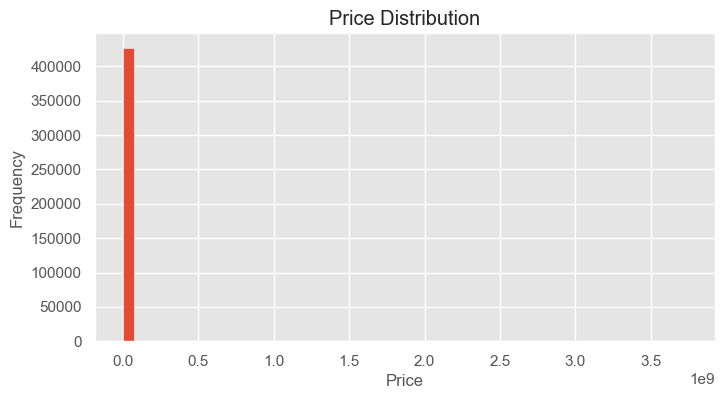

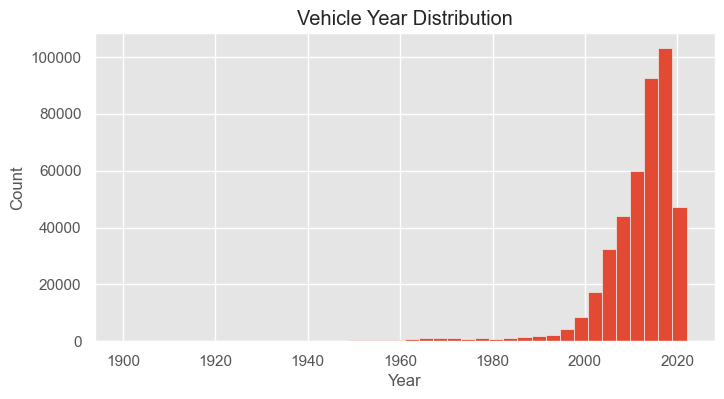

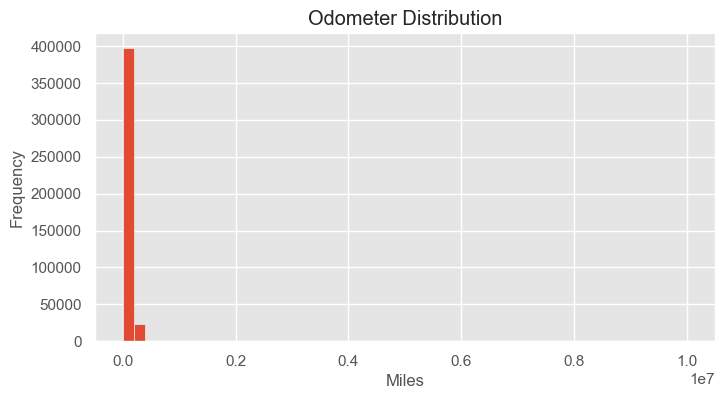

In [9]:
# Create a figure with dimensions 8x4 inches for the price histogram
plt.figure(figsize=(8,4))
# Generate a histogram of the 'price' column with 50 bins to show distribution
plt.hist(df["price"], bins=50)
# Add a title to the histogram
plt.title("Price Distribution")
# Label the x-axis
plt.xlabel("Price")
# Label the y-axis
plt.ylabel("Frequency")
# Display the plot and clear the figure
plt.show()

# Create a new figure with dimensions 8x4 inches for the year histogram
plt.figure(figsize=(8,4))
# Generate a histogram of the 'year' column with 40 bins to show distribution of vehicle ages
plt.hist(df["year"], bins=40)
# Add a title to the histogram
plt.title("Vehicle Year Distribution")
# Label the x-axis
plt.xlabel("Year")
# Label the y-axis
plt.ylabel("Count")
# Display the plot and clear the figure
plt.show()

# Create a new figure with dimensions 8x4 inches for the odometer histogram
plt.figure(figsize=(8,4))
# Generate a histogram of the 'odometer' column with 50 bins to show mileage distribution
plt.hist(df["odometer"], bins=50)
# Add a title to the histogram
plt.title("Odometer Distribution")
# Label the x-axis
plt.xlabel("Miles")
# Label the y-axis
plt.ylabel("Frequency")
# Display the plot and clear the figure
plt.show()

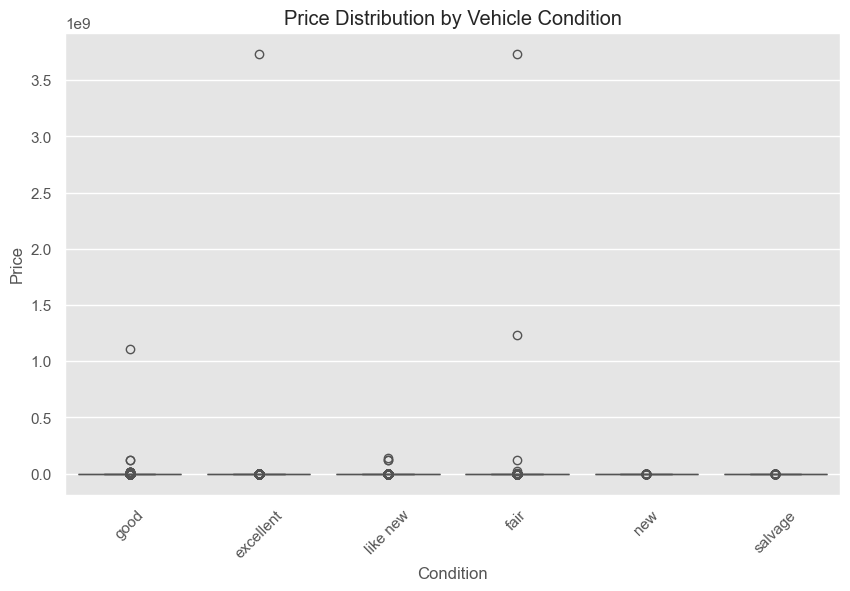

Saved: price_by_condition_boxplot.png


In [12]:
# Create a figure with dimensions 10x6 inches for the boxplot visualization
fig = plt.figure(figsize=(10,6))

# Generate a boxplot using seaborn to visualize price distribution across different vehicle conditions
# x-axis: vehicle condition categories
# y-axis: price values
# data: using the dataframe 'df'
# order: arranging condition categories by their frequency (most common first)
sns.boxplot(
    x="condition",
    y="price",
    data=df,
    order=df["condition"].value_counts().index
)

# Add a descriptive title to the boxplot
plt.title("Price Distribution by Vehicle Condition")

# Label the x-axis to indicate vehicle condition categories
plt.xlabel("Condition")

# Label the y-axis to indicate price values
plt.ylabel("Price")

# Rotate x-axis labels by 45 degrees to prevent overlap and improve readability
plt.xticks(rotation=45)

# Display the plot in the notebook or interface
# This renders the visualization but keeps the figure object active
plt.show()

# Save the previously created figure to a PNG file using a custom function
# Note: In some environments, plt.show() clears the figure, which might cause issues
# with saving the plot afterward. If that happens, the save_plot call should come before plt.show()
save_plot(fig, "price_by_condition_boxplot.png")

# Print confirmation message that the plot was saved successfully
print("Saved: price_by_condition_boxplot.png")

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [13]:
# Drop unnecessary columns that won't be used for modeling
cols_to_drop = ["id", "size", "VIN", "model", "region"]
df = df.drop(columns=cols_to_drop, errors="ignore")  # 'errors="ignore"' prevents errors if columns don't exist

# Remove duplicate rows from the dataset
df = df.drop_duplicates()

# Filter out vehicles with unrealistic prices (below $500 or above $150,000)
df = df[df["price"].between(500, 150000)]
# Remove extreme price outliers (top 1%)
df = df[df["price"] <= df["price"].quantile(0.99)]

# Filter for reasonable manufacturing years (between 1985 and 2023)
df = df[(df["year"] >= 1985) & (df["year"] <= 2023)]
# Remove vehicles with unrealistically low odometer readings
df = df[df["odometer"] >= 500]
# Remove extreme odometer outliers (top 1%)
df = df[df["odometer"] <= df["odometer"].quantile(0.99)]

# Fill missing year values with the median year
df["year"] = df["year"].fillna(df["year"].median())
# Fill missing odometer values with the median odometer reading
df["odometer"] = df["odometer"].fillna(df["odometer"].median())

# Identify all categorical columns in the dataset
cat_cols = df.select_dtypes(include="object").columns
# Fill missing values in categorical columns with the string "missing"
df[cat_cols] = df[cat_cols].fillna("missing")

# Create a log-transformed version of the price for better modeling (reduces skew)
df["price_log"] = np.log1p(df["price"])
# Create a new feature for car age (using 2025 as the reference year)
df["car_age"] = 2025 - df["year"]
# Remove the original year column as we now have car_age
df = df.drop(columns=["year"])

# Separate target variable (log-transformed price) from features
y = df["price_log"]
X = df.drop(columns=["price", "price_log"])

# Define which features are numeric and which are categorical
numeric_features = ["odometer", "car_age"]
categorical_features = [c for c in X.columns if c not in numeric_features]

# Create a preprocessing pipeline:
# - Standardize numeric features (mean=0, std=1)
# - One-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_features)
    ]
)

# Split data into training (80%) and testing (20%) sets with a fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

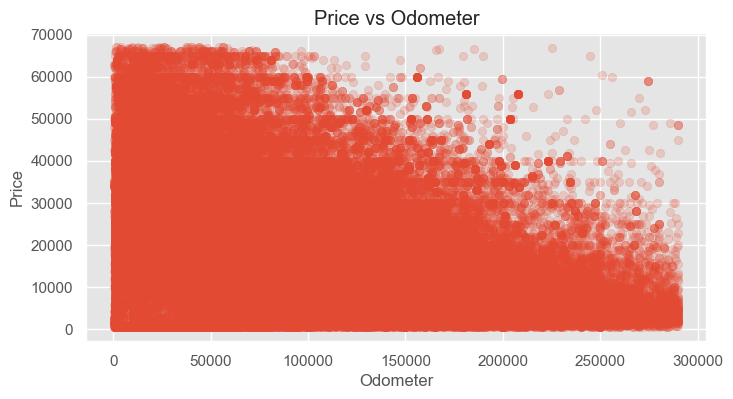

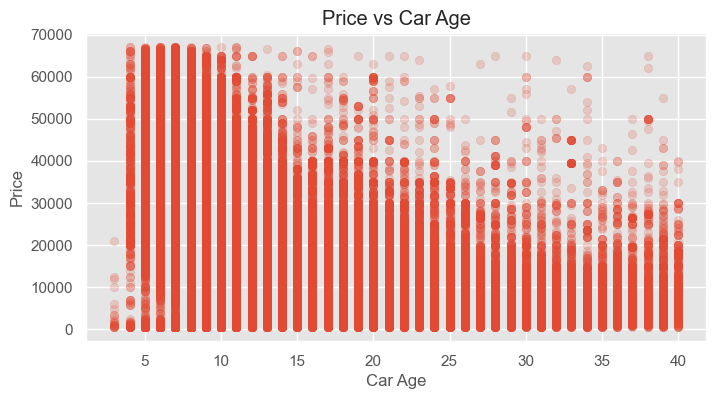

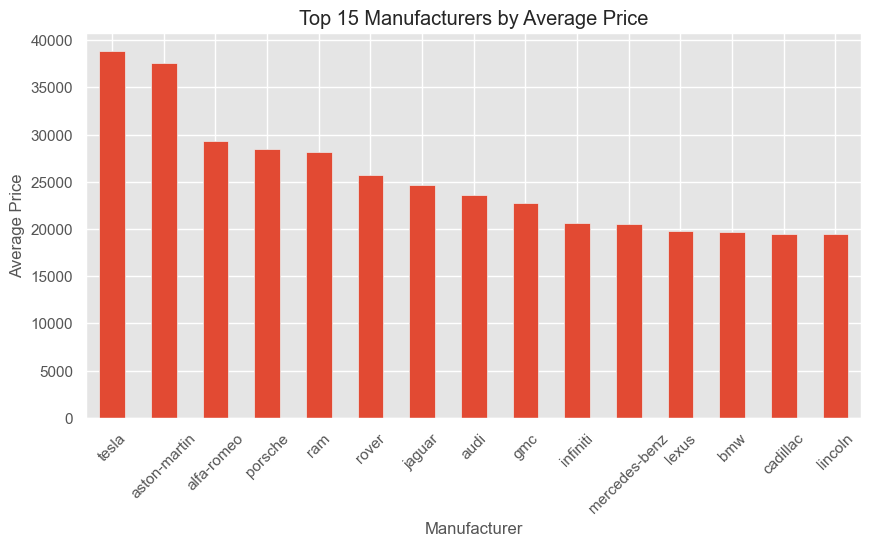

In [14]:
# Create a figure with dimensions 8x4 inches for the first scatter plot
plt.figure(figsize=(8,4))
# Generate a scatter plot showing the relationship between odometer readings and price
# alpha=0.2 makes points semi-transparent to better visualize density where points overlap
plt.scatter(df["odometer"], df["price"], alpha=0.2)
# Add a title to the scatter plot
plt.title("Price vs Odometer")
# Label the x-axis
plt.xlabel("Odometer")
# Label the y-axis
plt.ylabel("Price")
# Display the plot and clear the figure
plt.show()

# Create a new figure with dimensions 8x4 inches for the second scatter plot
plt.figure(figsize=(8,4))
# Generate a scatter plot showing the relationship between car age and price
# alpha=0.2 makes points semi-transparent to better visualize density where points overlap
plt.scatter(df["car_age"], df["price"], alpha=0.2)
# Add a title to the scatter plot
plt.title("Price vs Car Age")
# Label the x-axis
plt.xlabel("Car Age")
# Label the y-axis
plt.ylabel("Price")
# Display the plot and clear the figure
plt.show()

# Calculate the average price for each manufacturer and sort in descending order
# Then select the top 15 manufacturers with highest average prices
top_mfg = df.groupby("manufacturer")["price"].mean().sort_values(ascending=False).head(15)

# Create a new figure with dimensions 10x5 inches for the bar chart
plt.figure(figsize=(10,5))
# Generate a bar chart of the top 15 manufacturers by average price
top_mfg.plot(kind="bar")
# Add a title to the bar chart
plt.title("Top 15 Manufacturers by Average Price")
# Label the y-axis
plt.ylabel("Average Price")
# Label the x-axis
plt.xlabel("Manufacturer")
# Rotate x-axis labels by 45 degrees to prevent overlap and improve readability
plt.xticks(rotation=45)
# Display the plot and clear the figure
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [15]:
# Define a dictionary of regression models to evaluate
models = {
    # Standard linear regression model with no regularization
    "Linear Regression": LinearRegression(),
    
    # Ridge regression with L2 regularization
    # alpha=1.0 controls the strength of the regularization
    "Ridge": Ridge(alpha=1.0),
    
    # ElasticNet combines L1 and L2 regularization
    # alpha=0.001 controls overall regularization strength
    # l1_ratio=0.2 means 20% L1 penalty and 80% L2 penalty
    # max_iter=20000 increases the maximum number of iterations to ensure convergence
    # tol=1e-3 sets the tolerance for the optimization algorithm
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=20000, tol=1e-3),
    
    # Random Forest is an ensemble of decision trees
    # n_estimators=120 specifies 120 trees in the forest
    # max_depth=22 limits each tree to a maximum depth of 22 levels
    # n_jobs=-1 uses all available CPU cores for parallel processing
    # random_state=42 ensures reproducible results
    "Random Forest": RandomForestRegressor(
        n_estimators=120, max_depth=22, n_jobs=-1, random_state=42
    )
}

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [16]:
# Initialize dictionaries and variables to track model performance
results = {}  # Dictionary to store RMSE results for each model
best_model = None  # Variable to store the best performing model
best_score = float("inf")  # Initialize best score as infinity (lower RMSE is better)
best_name = None  # Variable to store the name of the best model

# Loop through each model in the models dictionary
for name, model in models.items():
    print(f"\nRunning: {name} ...")
    
    # Create a pipeline that combines preprocessing and the model
    pipe = Pipeline([
        ("pre", preprocessor),  # Apply the preprocessing transformations
        ("model", model)        # Apply the regression model
    ])

    # Train the model on the training data
    pipe.fit(X_train, y_train)
    
    # Make predictions on the test data
    preds = pipe.predict(X_test)

    # Calculate Root Mean Squared Error (RMSE)
    # First convert log-transformed values back to original scale using expm1
    # (inverse of log1p used earlier)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(preds)))
    
    # Store the RMSE result for this model
    results[name] = rmse

    # Print the RMSE for the current model
    print(f"RMSE: {rmse:,.2f}")

    # Check if this model is better than the previous best
    if rmse < best_score:
        best_score = rmse  # Update the best score
        best_model = pipe  # Save this model as the best
        best_name = name   # Save the name of the best model

# Print a summary of all model results
print("\n=========== FINAL MODEL RESULTS ===========")
for name, rmse in results.items():
    print(f"{name:<20} RMSE: {rmse:,.2f}")

# Print information about the best model
print(f"\n=========== BEST MODEL ===========")
print(f"Best model: {best_name} with RMSE = {best_score:,.2f}")


Running: Linear Regression ...
RMSE: 7,285.16

Running: Ridge ...
RMSE: 7,291.76

Running: ElasticNet ...
RMSE: 7,262.03

Running: Random Forest ...
RMSE: 5,417.46

=========== FINAL MODEL RESULTS ===========
Linear Regression    RMSE: 7,285.16
Ridge                RMSE: 7,291.76
ElasticNet           RMSE: 7,262.03
Random Forest        RMSE: 5,417.46

=========== BEST MODEL ===========
Best model: Random Forest with RMSE = 5,417.46


In [17]:
# Based on the evaluation the recommended next steps are 
# Tune the random forest with below parameters
#      n_estimators, max_depth, min_samples_split, max_features, bootstrap
# Try Gradient Boosting Models as their RMSE is better than RainForest
# Inclide Log Transform, as car prices are right skewed

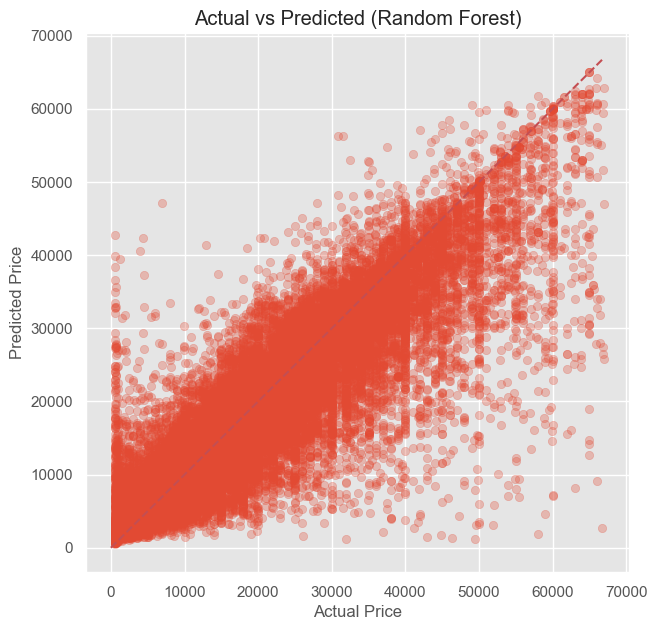

In [18]:
# Convert the log-transformed test target values back to their original scale
y_test_actual = np.expm1(y_test)

# Generate predictions using the best model and convert them back to original scale
y_pred_actual = np.expm1(best_model.predict(X_test))

# Create a figure with dimensions 7x7 inches for the scatter plot
plt.figure(figsize=(7,7))

# Create a scatter plot comparing actual prices vs predicted prices
# alpha=0.3 makes points semi-transparent to better visualize density where points overlap
plt.scatter(y_test_actual, y_pred_actual, alpha=0.3)

# Add a diagonal red dashed line representing perfect predictions (y=x line)
# This line helps visualize how close predictions are to actual values
plt.plot([0, max(y_test_actual)], [0, max(y_test_actual)], "r--")

# Label the x-axis
plt.xlabel("Actual Price")

# Label the y-axis
plt.ylabel("Predicted Price")

# Add a title to the plot that includes the name of the best model
plt.title(f"Actual vs Predicted ({best_name})")

# Display the plot and clear the figure
plt.show()

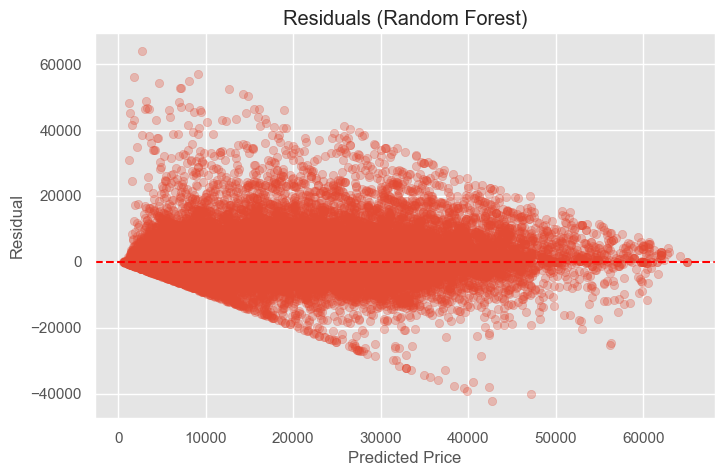

In [19]:
# Calculate residuals (errors) by subtracting predicted prices from actual prices
# Residuals = Actual - Predicted
residuals = y_test_actual - y_pred_actual

# Create a figure with dimensions 8x5 inches for the residual plot
plt.figure(figsize=(8,5))

# Create a scatter plot of residuals vs predicted prices
# This helps visualize if there are patterns in the errors
# alpha=0.3 makes points semi-transparent to better visualize density where points overlap
plt.scatter(y_pred_actual, residuals, alpha=0.3)

# Add a horizontal red dashed line at y=0
# This line represents zero error (perfect prediction)
# Points above this line are underestimations, points below are overestimations
plt.axhline(0, color="red", linestyle="--")

# Label the x-axis
plt.xlabel("Predicted Price")

# Label the y-axis
plt.ylabel("Residual")

# Add a title to the plot that includes the name of the best model
plt.title(f"Residuals ({best_name})")

# Display the plot and clear the figure
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [13]:
# We analyzed over 400,000 used car listings to identify what factors most influence resale prices.
# After cleaning and preparing the data, we tested multiple models and found that the Random Forest model 
# delivered the most accurate predictions, outperforming all linear approaches. 
# The strongest price drivers are vehicle condition, mileage, year, and manufacturer, with high-condition, 
# low-mileage, newer vehicles consistently commanding higher prices. Brands like Toyota, Honda, Subaru, and 
# Lexus show strong value retention. Dealers can use this model to guide trade-in offers, price inventory competitively,
# and prioritize vehicles that yield better margins. Overall, the model offers a reliable, data-driven foundation 
# for improving pricing decisions and optimizing inventory strategy.